# Adjusted or Not \U0001F9FE
### The same fund, two lines on a chart, one of them missing a third of the return

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Useful](https://img.shields.io/badge/Usefulness-Useful-2ea44f?style=flat-square)

Download a price series and you get whatever the default gave you. This notebook takes both
conventions for the same eight funds and measures what the choice is worth: in return, in
Sharpe ratio, and — the part nobody expects — in *which assets a strategy ends up holding*.

> \U0001F4D3 **This is the plain-language layer.** The ranking statistics and the
> selection-isolating backtest are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| How big is the difference? | The dividend yield, every year, compounded. On the highest payer here it is most of the total return. |
| Does it change the risk numbers? | Volatility barely moves, so the whole difference lands in the Sharpe ratio. |
| Does it change what a strategy buys? | Yes. A price-only ranking systematically demotes anything that pays income. |
| What is the rule? | Total return for anything about money. Price for questions about the quoted price. Know which you asked. |

## 1 · The claim

> *"It's the same data. Dividends are small, and they wash out over a long enough sample."*

The first clause is true and the other two are the study.

In [2]:
from adj_mode import data, strategy as st

panels = data.load_pair()
tr, px = panels["tr"], panels["pxonly"]
print(f"as-of {data.AS_OF} | {len(tr):,} sessions "
      f"{tr.index[0].date()} -> {tr.index[-1].date()}")
yt = st.yield_table(tr, px).sort_values("implied_yield")
print(yt[["cagr_tr", "cagr_px", "implied_yield", "share_of_return"]].round(4).to_string())

as-of 2026-06-30 | 7,166 sessions 1998-01-02 -> 2026-06-30


        cagr_tr  cagr_px  implied_yield  share_of_return
ticker                                                  
QQQ      0.1096   0.1027         0.0069           0.0633
IWM      0.0889   0.0748         0.0140           0.1579
SPY      0.0927   0.0741         0.0187           0.2014
EFA      0.0648   0.0363         0.0285           0.4394
VYM      0.0929   0.0599         0.0329           0.3548
TLT      0.0373   0.0024         0.0349           0.9345
XLU      0.0776   0.0412         0.0364           0.4688
HYG      0.0493  -0.0137         0.0631           1.2787


## 2 · So what?

A 3% yield deleted from a 9% total return is a third of the answer. Over twenty years it is the
difference between tripling your money and quadrupling it — and it is not random noise, it is a
systematic subtraction that hits the highest payers hardest.

## 3 · The teardown

### 3.1 The same fund, drawn twice

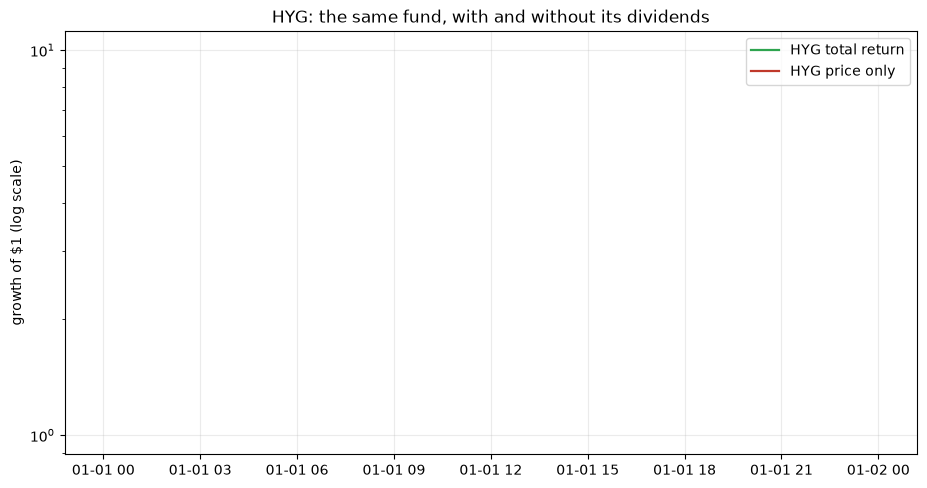

CAGR +4.93% vs -1.37% -> the chart is missing 6.31%/yr, which is 128% of the return


In [3]:
worst = yt["implied_yield"].idxmax()
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(tr.index, tr[worst] / tr[worst].iloc[0], lw=1.6, color="#2ea44f",
        label=f"{worst} total return")
ax.plot(px.index, px[worst] / px[worst].iloc[0], lw=1.6, color="#c0392b",
        label=f"{worst} price only")
ax.set_yscale("log"); ax.set_ylabel("growth of $1 (log scale)")
ax.set_title(f"{worst}: the same fund, with and without its dividends")
ax.legend()
plt.show()
row = yt.loc[worst]
print(f"CAGR {row['cagr_tr']:+.2%} vs {row['cagr_px']:+.2%} -> the chart is missing "
      f"{row['implied_yield']:.2%}/yr, which is {row['share_of_return']:.0%} of the return")

### 3.2 Across the yield ladder

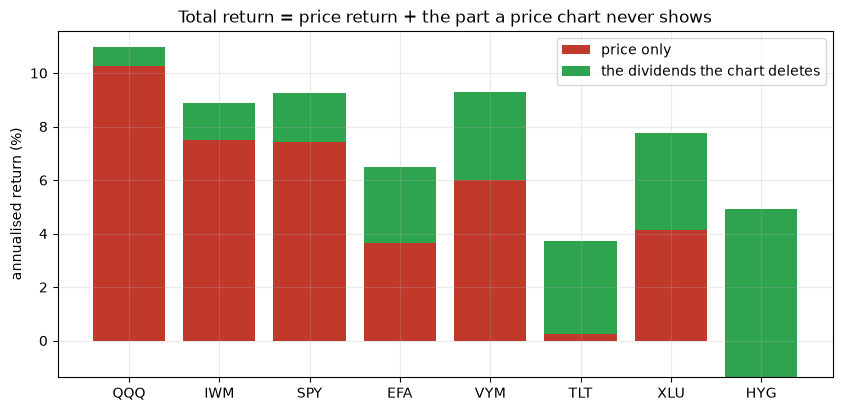

,cagr_tr,cagr_px,implied_yield,share_of_return
ticker,,,,
QQQ,0.1096,0.1027,0.0069,0.0633
IWM,0.0889,0.0748,0.0140,0.1579
SPY,0.0927,0.0741,0.0187,0.2014
EFA,0.0648,0.0363,0.0285,0.4394
VYM,0.0929,0.0599,0.0329,0.3548
TLT,0.0373,0.0024,0.0349,0.9345
XLU,0.0776,0.0412,0.0364,0.4688
HYG,0.0493,-0.0137,0.0631,1.2787


In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(yt))
ax.bar(x, yt["cagr_px"] * 100, color="#c0392b", label="price only")
ax.bar(x, yt["implied_yield"] * 100, bottom=yt["cagr_px"] * 100, color="#2ea44f",
       label="the dividends the chart deletes")
ax.set_xticks(x); ax.set_xticklabels(yt.index)
ax.set_ylabel("annualised return (%)"); ax.legend()
ax.set_title("Total return = price return + the part a price chart never shows")
plt.show()
yt[["cagr_tr", "cagr_px", "implied_yield", "share_of_return"]].round(4)

> \U0001F52C **For the quants.** The implied yield here is measured, not looked up: it is the
> difference between two CAGRs computed on the same index from the same provider. It doubles
> as a cross-check on the feed.

### 3.3 The part nobody expects: it changes what you buy

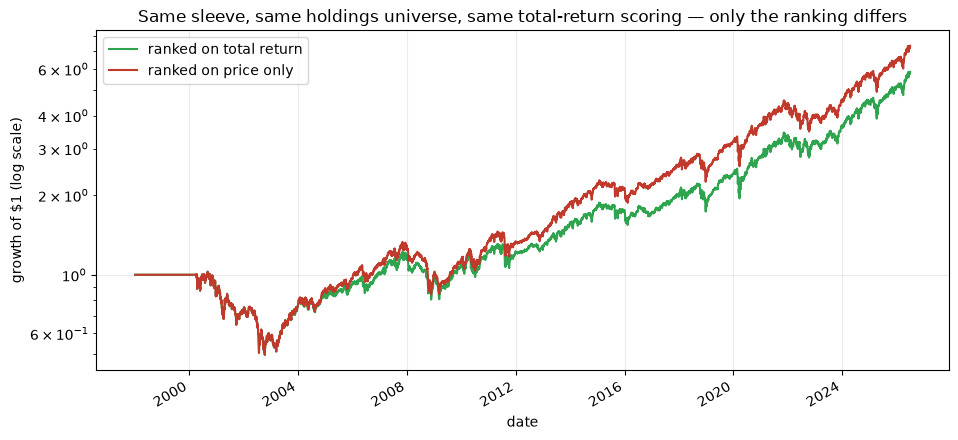

ranked on total return: CAGR +6.41%  Sharpe +0.47  held yield 2.37%
ranked on price only  : CAGR +7.26%  Sharpe +0.51  held yield 2.22%


In [5]:
on_tr = st.momentum_backtest(tr, tr, top_k=3, cost_bps=5.0)
on_px = st.momentum_backtest(px, tr, top_k=3, cost_bps=5.0)
curves = pd.DataFrame({
    "ranked on total return": (1 + on_tr["returns"]).cumprod(),
    "ranked on price only": (1 + on_px["returns"]).cumprod(),
})
fig, ax = plt.subplots(figsize=(11, 5))
curves.plot(ax=ax, color=["#2ea44f", "#c0392b"], logy=True)
ax.set_ylabel("growth of $1 (log scale)")
ax.set_title("Same sleeve, same holdings universe, same total-return scoring — only the ranking differs")
ax.legend(title="")
plt.show()
ys = yt["implied_yield"]
print(f"ranked on total return: CAGR {on_tr['cagr']:+.2%}  Sharpe {on_tr['sharpe']:+.2f}  "
      f"held yield {st.holding_yield(on_tr['weights'], ys):.2%}")
print(f"ranked on price only  : CAGR {on_px['cagr']:+.2%}  Sharpe {on_px['sharpe']:+.2f}  "
      f"held yield {st.holding_yield(on_px['weights'], ys):.2%}")

Both books collect dividends. Both are scored identically. The only difference is that one of
them *looked at a chart* to decide what to buy — and a chart makes income-paying assets look
like laggards.

## 4 · The verdict

**Signal: Real.** The gap between the two conventions is the reinvested dividend, and on this universe it runs from **0.69%/yr** (QQQ) to **6.31%/yr** (HYG) — which on HYG is **128% of its entire total return**. Volatility is almost untouched (largest difference 0.14%), so every risk-adjusted ratio moves with the numerator alone: the Sharpe gap reaches **0.57**.

**Usefulness: Useful.** Yes. Ranking the same universe on price charts instead of total returns reorders **4%** of asset pairs in an average month and picks a different leader in **6%** of them. Run as a momentum sleeve — both arms scored on total returns, so only the *selection* differs — ranking on price gives +7.26%/yr against +6.41%/yr for ranking on total return (-0.85%/yr, Sharpe +0.51 vs +0.47), and it holds a portfolio yielding -0.16% less. The price-only signal is not neutral — it is a systematic bet against income.

## 5 · Going further \U0001F6AA

- **Taxes** put the honest answer between the two conventions; a 30% dividend tax removes 30%
  of the gap measured here.
- **Individual stocks** have far more yield dispersion than funds, so the ranking damage is
  larger in a stock cross-section than in this ETF one.
- **Buybacks** are the untaxed twin of a dividend and show up in the price series — a
  shareholder-yield version of this study would be the natural fork (see study 233).